In [7]:
import sys
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import geopandas as gpd
from shapely.geometry import mapping
from scipy.stats import spearmanr, pearsonr
import ts_onset_cess as ocd
import pandas as pd
from fapar_def import fapar_read

import warnings
warnings.filterwarnings('ignore')

In [8]:
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"

### Read in calculated recycling to add to the precipitation plots

In [9]:
Y1=2018
Y2=2024

#datao ="/Volumes/ESA_F4R/ed_prepare/2026_rho/mint_r02_it1000_tole3/bands_rho/" 
datao = "/Volumes/ESA_F4R/ed_prepare/2026_rho/no_ocean_r02_it1000_tole3/"
S_NAME = "S_SE" # S_SE or S_LSE 
L_NAME = "L_M" # L_M or L_HI
band = {'N':[5,12,10,31],'EQ':[-5,5,8,29],'S':[-15,-5,12,31]}
rho_xarr={}
for B in ['N','EQ','S']:
    print('running band:', B)
    #rho_xarr[B] = xr.open_mfdataset(datao+L_NAME+"_"+S_NAME+"_band_"+B+"_rot_rho_era5_*.nc",engine='netcdf4')
    rho_xarr[B] = xr.open_mfdataset(datao+"no_ocean_"+L_NAME+"_"+S_NAME+"_band_"+B+"_rot_rho_era5_*.nc",engine='netcdf4')
    rho_xarr[B] = rho_xarr[B].sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))

running band: N
running band: EQ
running band: S


### Calculate roatational means for each month and band


In [10]:
#Monthly average plots - average rotation
rho_mon = {}
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for B in ['N','EQ','S']:
    rho_rot = rho_xarr[B]['rho'].mean('rot') 
    rho_mon[B] = rho_rot.groupby('time.month').mean(dim=('time','lat','lon'))
    rho_mon[B] = rho_mon[B].assign_coords(dayofyear=('month', [15,45,74,105,135,166,196,227,258,288,319,349]))
        

In [11]:
#fapar_in = fapar_read()
#fapar = xr.Dataset()
#fapar['N'] = fapar_in.sel(lat=slice(5,12),lon=slice(10,31)).mean(dim=('lat','lon'))
#fapar['EQ'] = fapar_in.sel(lat=slice(-5,5),lon=slice(8,29)).mean(dim=('lat','lon'))
#fapar['S'] = fapar_in.sel(lat=slice(-15,-5),lon=slice(12,31)).mean(dim=('lat','lon'))
#
#fapar.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/fapar_bands.nc')

In [12]:
fapar = xr.open_mfdataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/fapar_bands.nc')
print(fapar)
#fapar = fapar.sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))

<xarray.Dataset> Size: 12kB
Dimensions:  (time: 364)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2014-01-10 2014-01-20 ... 2024-11-30
Data variables:
    N        (time) float64 3kB dask.array<chunksize=(364,), meta=np.ndarray>
    EQ       (time) float64 3kB dask.array<chunksize=(364,), meta=np.ndarray>
    S        (time) float64 3kB dask.array<chunksize=(364,), meta=np.ndarray>


### Read in TROPOMI (2018-2024)

In [13]:
#tropomi = xr.Dataset()
#tlistN = []
#tlistEQ = []
#tlistS = []
#qflag = 0.7
#for Y in range(2018,2025):
#    print('running year: ',str(Y))
#    tin = xr.open_dataset("/Volumes/ESA_F4R/tropomi/merged/TROPOMI_merged_"+str(Y)+".nc")
#    tlistN.append(tin.where((tin['qa_value']>qflag) & (tin.lat < 12.) & (tin.lat > 5.) & (tin.lon < 31.) & (tin.lon > 10.),drop=True).mean(dim=('ground_pixel','scanline'))['deltad'])
#    tlistEQ.append(tin.where((tin['qa_value']>qflag) & (tin.lat < 5.) & (tin.lat > -5.) & (tin.lon < 29.) & (tin.lon > 8.),drop=True).mean(dim=('ground_pixel','scanline'))['deltad'])
#    tlistS.append(tin.where((tin['qa_value']>qflag) & (tin.lat < -5.) & (tin.lat > -15.) & (tin.lon < 31.) & (tin.lon > 12.),drop=True).mean(dim=('ground_pixel','scanline'))['deltad'])
#tropomi['N'] = xr.concat(tlistN,dim='time')
#tropomi['EQ'] = xr.concat(tlistEQ,dim='time')
#tropomi['S'] = xr.concat(tlistS,dim='time')
#
#tropomi.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/tropomi_bands.nc')

In [14]:
tropomi = xr.open_mfdataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/tropomi_bands.nc')
tropomi = tropomi.sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))

### Read in precip 
- do this for whole available ts and then sub-select years in next step for analysis

In [15]:
#Y1=1981
#Y2=2025
#for Y in range(Y1,Y2+1):
#    prp = xr.open_mfdataset('/Volumes/blue_wd/chirps_daily/chirps-v2.0.'+str(Y)+'.days_p05.nc')['precip']
#    prp = prp.rename({'latitude':'lat','longitude':'lon'})
#    prpN = prp.sel(lat=slice(5,12),lon=slice(10,31),drop=True).load()
#    prpEQ = prp.sel(lat=slice(-5,5),lon=slice(8,29),drop=True).load()
#    prpS = prp.sel(lat=slice(-15,-5),lon=slice(12,31),drop=True).load()
#    if Y==Y1:
#        prpaN = prpN
#        prpaEQ = prpEQ
#        prpaS = prpS
#    else:
#        prpaN = xr.concat([prpaN,prpN],dim='time')
#        prpaEQ = xr.concat([prpaEQ,prpEQ],dim='time')
#        prpaS = xr.concat([prpaS,prpS],dim='time')
#        prpN.close()
#        prpEQ.close()
#        prpS.close()
#prpaN.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_N.nc',engine='h5netcdf')
#prpaN.close()
#prpaEQ.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_EQ.nc',engine='h5netcdf')
#prpaEQ.close()
#prpaS.to_netcdf('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_S.nc',engine='h5netcdf')
#prpaS.close()
#        

In [ ]:
pr = {}
prp = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_N.nc')['precip']
pr['N'] = prp.sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))
prp = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_EQ.nc')['precip']
pr['EQ'] = prp.sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))
prp = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/chirps_S.nc')['precip']
pr['S'] = prp.sel(time=slice(str(Y1)+'-01-01',str(Y2)+'-12-31'))


## Equatorial Band

- Checking to see if wet and dry seasons have consistently different onset and cessation dates

- Calculate wet and dry season composites for season 1 and season 2

- Calculate the onset and cessation of full climatology for all seasons

- Calculate onset and cessation of wet and dry composite seasons

- Calculate mean of onset and cessation composites

- Plot everything

In [17]:
#Equatorial Band

P = pr['EQ'] 
FP = fapar['EQ']
FP = FP.groupby('time.dayofyear').mean('time')

TP = tropomi['EQ']
TP = TP.groupby('time.dayofyear').mean('time')

#Composite season years - S1
PA = P.mean(dim=('lat','lon')).where(P['time.dayofyear']<200).groupby('time.year').mean('time')
sort_index = PA.sortby(PA)
dryS1 = sort_index[0:5]['year']
wetS1 = sort_index[-5:]['year']
print('Dry years S1',dryS1['year'].values)
print('Wet years S1',wetS1['year'].values)
PW1 = P.sel(time=P['time.year'].isin(wetS1['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
PD1 = P.sel(time=P['time.year'].isin(dryS1['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
#Composite season years - S2
PA = P.mean(dim=('lat','lon')).where(P['time.dayofyear']>200).groupby('time.year').mean('time')
sort_index = PA.sortby(PA)
dryS2 = sort_index[0:5]['year']
wetS2 = sort_index[-5:]['year']
print('Dry years S2',dryS2['year'].values)
print('Wet years S2',wetS2['year'].values)
PW2 = P.sel(time=P['time.year'].isin(wetS2['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
PD2 = P.sel(time=P['time.year'].isin(dryS2['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
print('----------------------------------------------------')



Dry years S1 [2024 2020 2022 2018 2019]
Wet years S1 [2022 2018 2019 2021 2023]
Dry years S2 [2024 2021 2020 2023 2022]
Wet years S2 [2020 2023 2022 2019 2018]
----------------------------------------------------


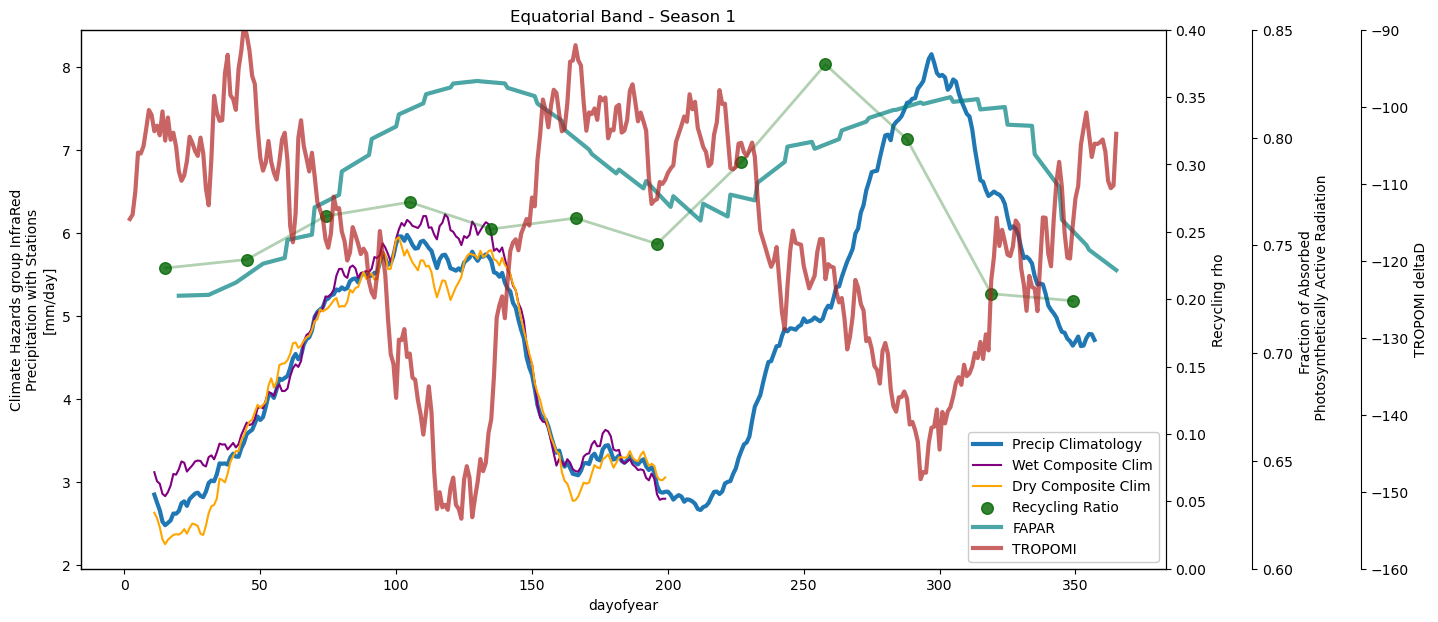

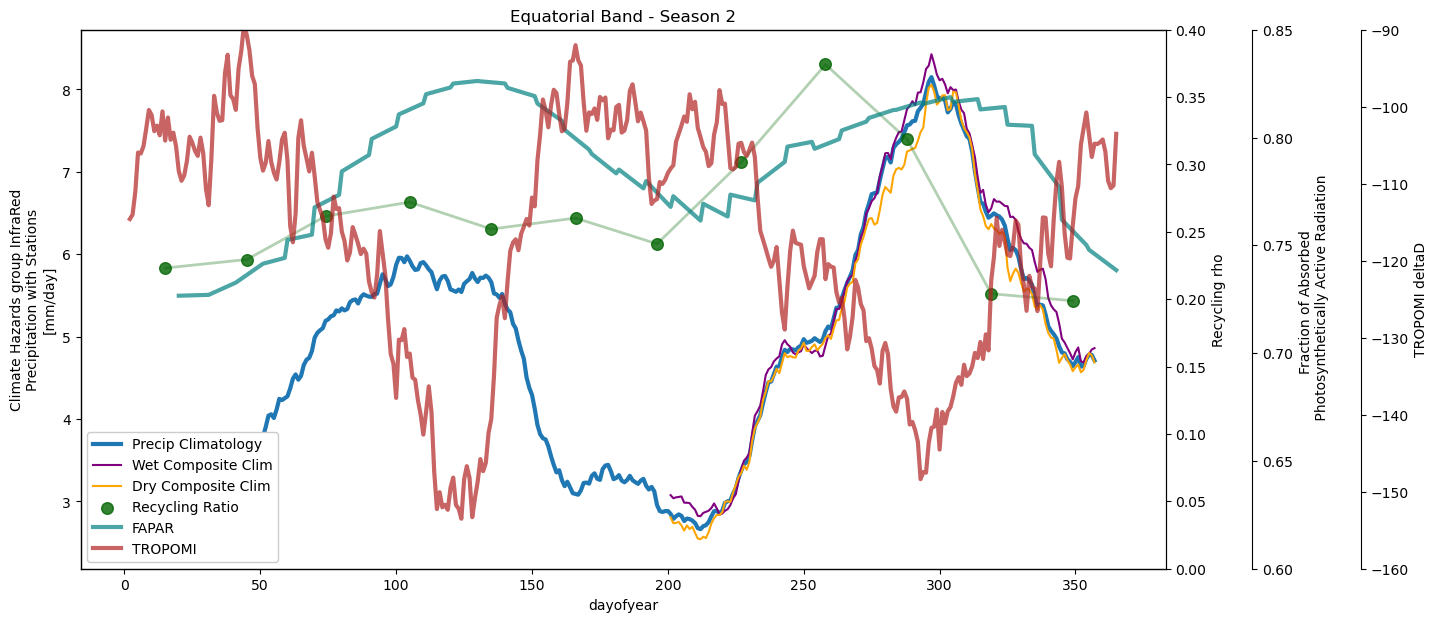

In [18]:
#Plot everything - SEASON 1

fig,ax = plt.subplots(figsize=(14, 7))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

PW1R = PW1.rolling(dayofyear=20, center=True).mean('dayofyear').where(PW1['dayofyear']<200)
PD1R = PD1.rolling(dayofyear=20, center=True).mean('dayofyear').where(PW1['dayofyear']<200)
PW1R.plot(linestyle='-',color='purple',alpha=1,label="Wet Composite Clim")
PD1R.plot(linestyle='-',color='orange',alpha=1,label="Dry Composite Clim")

ax2 = ax.twinx()
ax3 = ax.twinx()
ax4 = ax.twinx()
ax3.spines.right.set_position(("axes", 1.08))
ax4.spines.right.set_position(("axes", 1.18))

ax2.plot(rho_mon['EQ']['dayofyear'],rho_mon['EQ'],linestyle='-',linewidth=2,color='darkgreen',alpha=0.3)
ax2.scatter(rho_mon['EQ']['dayofyear'],rho_mon['EQ'],s=70,color='darkgreen',label='Recycling Ratio',alpha=0.8)
ax2.set(ylim=(0,0.4), ylabel='Recycling rho')

FPR = FP.rolling(dayofyear=3, center=True).mean('dayofyear')
ax3.plot(FPR['dayofyear'],FPR,linestyle='-',linewidth=3,color='teal',alpha=0.7,label='FAPAR')
ax3.set(ylim=(0.6,0.85),ylabel='Fraction of Absorbed \n Photosynthetically Active Radiation')

TPR = TP.rolling(dayofyear=3, center=True).mean('dayofyear')
ax4.plot(TPR['dayofyear'],TPR,linestyle='-',linewidth=3,color='firebrick',alpha=0.7,label='TROPOMI')
ax4.set(ylim=(-160,-90),ylabel='TROPOMI deltaD')

# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2 + lines3 + lines4, labels + labels2 + labels3 + labels4, framealpha=1.0, loc='lower right')

plt.title('Equatorial Band - Season 1')
plt.savefig(datap+'EQ_S1_clim_pres.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()
plt.close()


#Plot everything - SEASON 2

fig,ax = plt.subplots(figsize=(14, 7))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

PW2R = PW2.rolling(dayofyear=20, center=True).mean('dayofyear').where(PW2['dayofyear']>200)
PD2R = PD2.rolling(dayofyear=20, center=True).mean('dayofyear').where(PW2['dayofyear']>200)
PW2R.plot(linestyle='-',color='purple',alpha=1,label="Wet Composite Clim")
PD2R.plot(linestyle='-',color='orange',alpha=1,label="Dry Composite Clim")

ax2 = ax.twinx()
ax3 = ax.twinx()
ax4 = ax.twinx()
ax3.spines.right.set_position(("axes", 1.08))
ax4.spines.right.set_position(("axes", 1.18))

ax2.plot(rho_mon['EQ']['dayofyear'],rho_mon['EQ'],linestyle='-',linewidth=2,color='darkgreen',alpha=0.3)
ax2.scatter(rho_mon['EQ']['dayofyear'],rho_mon['EQ'],s=70,color='darkgreen',label='Recycling Ratio',alpha=0.8)
ax2.set(ylim=(0,0.4),ylabel='Recycling rho')

FPR = FP.rolling(dayofyear=3, center=True).mean('dayofyear')
ax3.plot(FPR['dayofyear'],FPR,linestyle='-',linewidth=3,color='teal',alpha=0.7,label='FAPAR')
ax3.set(ylim=(0.6,0.85),ylabel='Fraction of Absorbed \n Photosynthetically Active Radiation')

TPR = TP.rolling(dayofyear=3, center=True).mean('dayofyear')
ax4.plot(TPR['dayofyear'],TPR,linestyle='-',linewidth=3,color='firebrick',alpha=0.7,label='TROPOMI')
ax4.set(ylim=(-160,-90),ylabel='TROPOMI deltaD')

# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2 + lines3 + lines4, labels + labels2 + labels3 + labels4, framealpha=1.0, loc='lower left')

plt.title('Equatorial Band - Season 2')
plt.savefig(datap+'EQ_S2_clim_pres.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()
plt.close()


In [19]:
#North Band

P = pr['N'] 
FP = fapar['N']
FP = FP.groupby('time.dayofyear').mean('time')

TP = tropomi['N']
TP = TP.groupby('time.dayofyear').mean('time')

#Composite season years - S1
PA = P.mean(dim=('lat','lon')).groupby('time.year').mean('time')
sort_index = PA.sortby(PA)
dryS1 = sort_index[0:5]['year']
wetS1 = sort_index[-5:]['year']
print('Dry years S1',dryS1['year'].values)
print('Wet years S1',wetS1['year'].values)
PW1 = P.sel(time=P['time.year'].isin(wetS1['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
PD1 = P.sel(time=P['time.year'].isin(dryS1['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
print('----------------------------------------------------')



Dry years S1 [2020 2024 2018 2021 2022]
Wet years S1 [2018 2021 2022 2023 2019]
----------------------------------------------------


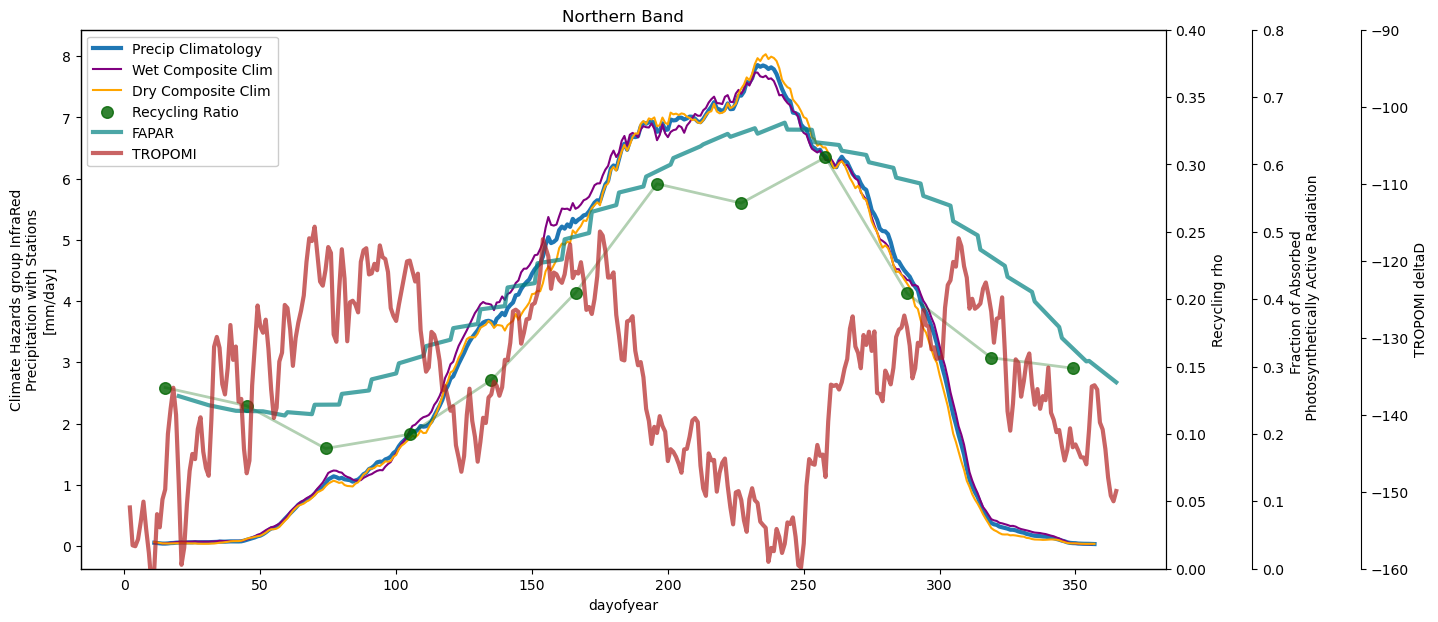

<Figure size 640x480 with 0 Axes>

In [20]:
#Plot everything - SEASON 1

fig,ax = plt.subplots(figsize=(14, 7))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

PW1R = PW1.rolling(dayofyear=20, center=True).mean('dayofyear')
PD1R = PD1.rolling(dayofyear=20, center=True).mean('dayofyear')
PW1R.plot(linestyle='-',color='purple',alpha=1,label="Wet Composite Clim")
PD1R.plot(linestyle='-',color='orange',alpha=1,label="Dry Composite Clim")

ax2 = ax.twinx()
ax3 = ax.twinx()
ax4 = ax.twinx()
ax3.spines.right.set_position(("axes", 1.08))
ax4.spines.right.set_position(("axes", 1.18))

ax2.plot(rho_mon['N']['dayofyear'],rho_mon['N'],linestyle='-',linewidth=2,color='darkgreen',alpha=0.3)
ax2.scatter(rho_mon['N']['dayofyear'],rho_mon['N'],s=70,color='darkgreen',label='Recycling Ratio',alpha=0.8)
ax2.set(ylim=(0,0.4),ylabel='Recycling rho')

FPR = FP.rolling(dayofyear=3, center=True).mean('dayofyear')
ax3.plot(FPR['dayofyear'],FPR,linestyle='-',linewidth=3,color='teal',alpha=0.7,label='FAPAR')
ax3.set(ylim=(0.0,0.8),ylabel='Fraction of Absorbed \n Photosynthetically Active Radiation')

TPR = TP.rolling(dayofyear=3, center=True).mean('dayofyear')
ax4.plot(TPR['dayofyear'],TPR,linestyle='-',linewidth=3,color='firebrick',alpha=0.7,label='TROPOMI')
ax4.set(ylim=(-160,-90),ylabel='TROPOMI deltaD')

# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2 + lines3 + lines4, labels + labels2 + labels3 + labels4, framealpha=1.0, loc='upper left')

plt.title('Northern Band')
plt.savefig(datap+'N_S1_clim_pres.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()

In [21]:
#Southern Band

P = pr['S'] 
FP = fapar['S']
FP = FP.groupby('time.dayofyear').mean('time')

TP = tropomi['S']
TP = TP.groupby('time.dayofyear').mean('time')

#Composite season years - S1
PA = P.mean(dim=('lat','lon')).groupby('time.year').mean('time')
sort_index = PA.sortby(PA)
dryS1 = sort_index[0:5]['year']
wetS1 = sort_index[-5:]['year']
print('Dry years S1',dryS1['year'].values)
print('Wet years S1',wetS1['year'].values)
PW1 = P.sel(time=P['time.year'].isin(wetS1['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
PD1 = P.sel(time=P['time.year'].isin(dryS1['year'].values)).groupby('time.dayofyear').mean(dim=('time','lat','lon'))
print('----------------------------------------------------')


Dry years S1 [2024 2021 2020 2022 2018]
Wet years S1 [2020 2022 2018 2019 2023]
----------------------------------------------------


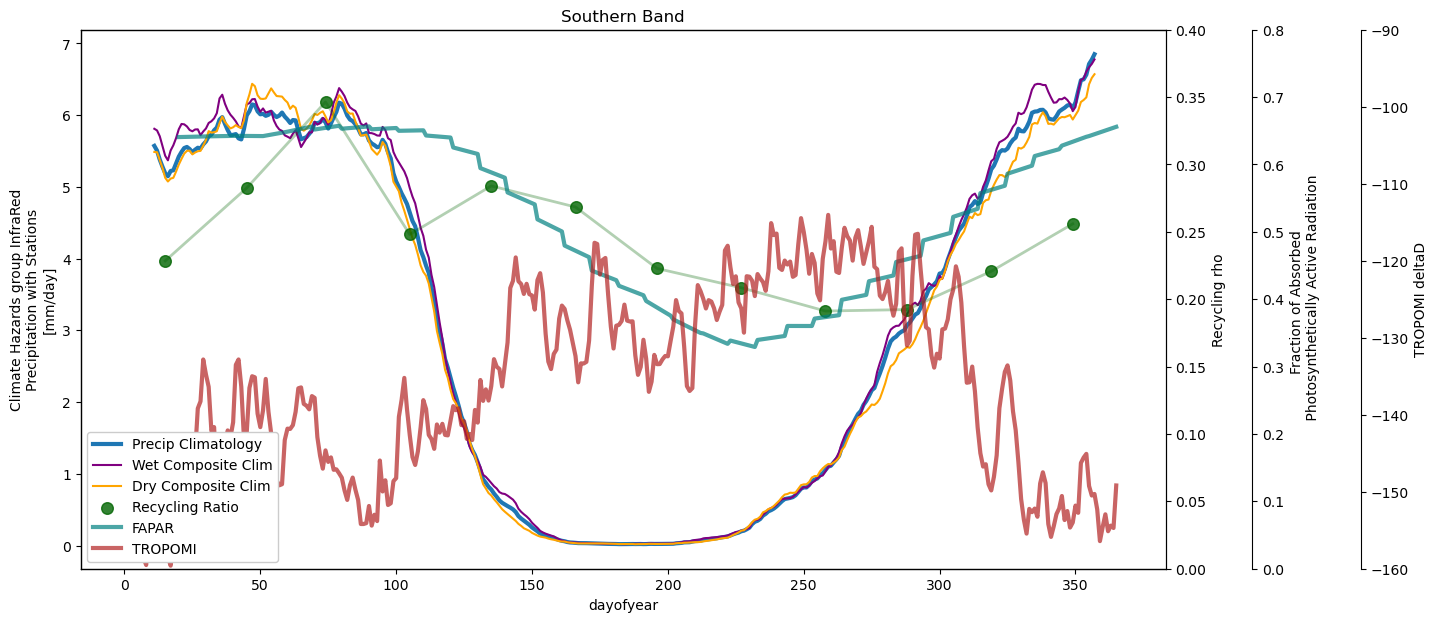

<Figure size 640x480 with 0 Axes>

In [22]:
#Plot everything - SEASON 1

fig,ax = plt.subplots(figsize=(14, 7))
Pdays = P.mean(dim = ('lat','lon')).groupby('time.dayofyear').mean(dim = ('time'))
PplotR = Pdays.rolling(dayofyear=20, center=True).mean('dayofyear')
PplotR.plot(linewidth=3,label='Precip Climatology')

PW1R = PW1.rolling(dayofyear=20, center=True).mean('dayofyear')
PD1R = PD1.rolling(dayofyear=20, center=True).mean('dayofyear')
PW1R.plot(linestyle='-',color='purple',alpha=1,label="Wet Composite Clim")
PD1R.plot(linestyle='-',color='orange',alpha=1,label="Dry Composite Clim")

ax2 = ax.twinx()
ax3 = ax.twinx()
ax4 = ax.twinx()
ax3.spines.right.set_position(("axes", 1.08))
ax4.spines.right.set_position(("axes", 1.18))

ax2.plot(rho_mon['S']['dayofyear'],rho_mon['S'],linestyle='-',linewidth=2,color='darkgreen',alpha=0.3)
ax2.scatter(rho_mon['S']['dayofyear'],rho_mon['S'],s=70,color='darkgreen',label='Recycling Ratio',alpha=0.8)
ax2.set(ylim=(0,0.4),ylabel='Recycling rho')

FPR = FP.rolling(dayofyear=3, center=True).mean('dayofyear')
ax3.plot(FPR['dayofyear'],FPR,linestyle='-',linewidth=3,color='teal',alpha=0.7,label='FAPAR')
ax3.set(ylim=(0.0,0.8),ylabel='Fraction of Absorbed \n Photosynthetically Active Radiation')

TPR = TP.rolling(dayofyear=3, center=True).mean('dayofyear')
ax4.plot(TPR['dayofyear'],TPR,linestyle='-',linewidth=3,color='firebrick',alpha=0.7,label='TROPOMI')
ax4.set(ylim=(-160,-90),ylabel='TROPOMI deltaD')

# Get the line legends from the axis
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()

# Add a legend to the figure
plt.legend(lines + lines2 + lines3 + lines4, labels + labels2 + labels3 + labels4, framealpha=1.0, loc='lower left')

plt.title('Southern Band')
plt.savefig(datap+'S_S1_clim_pres.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()
plt.clf()